# FinTrustX: Explainable AI Platform for Secure Credit Risk Assessment and Loan Decision Intelligence

**Exploratory Data Analysis | Home Credit Default Risk**  
**Author:** FinTrustX Data Science Team  
**Date:** August 2026 | **Python:** 3.12

## Notebook objective

This notebook establishes a trustworthy understanding of the Home Credit training data before preprocessing or modelling. It documents data quality, default behaviour, and feature patterns so later credit-risk models are accurate, explainable, and governed responsibly.

## Table of Contents

1. [Introduction](#1-introduction)
2. [Import Libraries](#2-import-libraries)
3. [Load Dataset](#3-load-dataset)
4. [Dataset Overview](#4-dataset-overview)
5. [Missing Value Analysis](#5-missing-value-analysis)
6. [Duplicate Analysis](#6-duplicate-analysis)
7. [Target Variable Analysis](#7-target-variable-analysis)
8. [Numerical Feature Analysis](#8-numerical-feature-analysis)
9. [Categorical Feature Analysis](#9-categorical-feature-analysis)
10. [Correlation Analysis](#10-correlation-analysis)
11. [Outlier Analysis](#11-outlier-analysis)
12. [Feature Distribution](#12-feature-distribution)
13. [Key Business Insights](#13-key-business-insights)
14. [Data Quality Report](#14-data-quality-report)
15. [Conclusion](#15-conclusion)

# 1 Introduction

Credit risk is the likelihood that a borrower will not repay as agreed. Default prediction estimates this risk from applicant information, helping lenders make consistent decisions. Explainable AI matters because a score alone cannot show why risk was assigned, whether data quality influenced it, or whether a feature is acting as an inappropriate proxy. This EDA identifies those risks before modelling. The expected outcome is an auditable evidence base for preprocessing and transparent loan-decision intelligence.

# 2 Import Libraries

These libraries provide reproducible data inspection and high-quality visualisation. Version reporting supports auditability, while consistent styling makes analytical comparisons clear to recruiters, professors, and model-governance stakeholders.

In [2]:
from __future__ import annotations
import platform
import warnings
from pathlib import Path
from typing import Iterable
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
try:
    import missingno as msno
except ImportError as error:
    raise ImportError("Install missingno with: pip install missingno") from error

warnings.filterwarnings("ignore")
RANDOM_STATE, TARGET = 42, "TARGET"
def find_project_root(anchor_dirs=('src', 'data', 'models'), max_upward=4) -> Path:
    current = Path.cwd().resolve()
    if (current / 'Credit-risk-ai' / 'src').is_dir():
        return (current / 'Credit-risk-ai').resolve()
    for _ in range(max_upward):
        if all((current / marker).exists() for marker in anchor_dirs):
            return current
        if current.parent == current:
            break
        current = current.parent
    if (Path.cwd() / 'src').exists():
        return Path.cwd().resolve()
    if (Path.cwd().parent / 'src').exists():
        return Path.cwd().parent.resolve()
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" 
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
display(pd.Series({"Python": platform.python_version(), "NumPy": np.__version__, "Pandas": pd.__version__, "Matplotlib": matplotlib.__version__, "Seaborn": sns.__version__}, name="Version").to_frame())


,Version
Python,3.13.2
NumPy,2.4.6
Pandas,3.0.5
Matplotlib,3.11.1
Seaborn,0.13.2


# 3 Load Dataset

We inspect the beginning, end, and a reproducible random sample to validate ingestion and schema assumptions. Memory consumption matters because credit datasets are wide and must remain practical for downstream training and deployment.

In [3]:
def find_train_file(data_dir: Path) -> Path:
    """Locate the Home Credit training file in supported project locations."""
    for path in [data_dir/"train.csv", data_dir/"raw/train.csv", data_dir/"application_train.csv", data_dir/"raw/application_train.csv"]:
        if path.exists():
            return path
    raise FileNotFoundError("Place train.csv or application_train.csv in data/ or data/raw/.")

train_path = find_train_file(DATA_DIR)
df = pd.read_csv(train_path)
print(f"Loaded: {train_path}\nShape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1_048_576:.2f} MB")
display(pd.DataFrame({"column": df.columns}))
display(df.head()); display(df.tail()); display(df.sample(min(5, len(df)), random_state=RANDOM_STATE))

Loaded: D:\Projects\Credit-risk-ai\data\raw\application_train.csv
Shape: 307,511 rows × 122 columns
Memory usage: 504.99 MB


,column
0,SK_ID_CURR
1,TARGET
2,NAME_CONTRACT_TYPE
3,CODE_GENDER
4,FLAG_OWN_CAR
...,...
117,AMT_REQ_CREDIT_BUREAU_DAY
118,AMT_REQ_CREDIT_BUREAU_WEEK
119,AMT_REQ_CREDIT_BUREAU_MON
120,AMT_REQ_CREDIT_BUREAU_QRT


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
245895,384575,0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
98194,214010,0,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
36463,142232,0,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
249923,389171,0,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
158389,283617,0,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0


# 4 Dataset Overview

The feature profile separates numerical, categorical, and boolean variables because they require different preprocessing. Summary statistics reveal range and scale; categorical summaries reveal vocabulary. Business-wise, this describes the evidence available to underwriting, while ML-wise it determines imputation, encoding, and scaling choices.

In [4]:
def feature_groups(frame: pd.DataFrame) -> dict[str, list[str]]:
    """Group columns by analytical type."""
    return {"numerical": frame.select_dtypes(include=np.number).columns.tolist(), "categorical": frame.select_dtypes(include=["object", "category"]).columns.tolist(), "boolean": frame.select_dtypes(include=["bool"]).columns.tolist()}

groups = feature_groups(df)
df.info()
display(df.describe().T)
display(df.describe(include=["object", "category"]).T)
display(pd.Series({"Rows": len(df), "Columns": df.shape[1], "Numerical features": len(groups["numerical"]), "Categorical features": len(groups["categorical"]), "Boolean features": len(groups["boolean"])}, name="Count").to_frame())

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


,Count
Rows,307511
Columns,122
Numerical features,106
Categorical features,16
Boolean features,0


# 5 Missing Value Analysis

Missing values may indicate unavailable documents, inapplicable products, or operational collection gaps—not simply bad data. Their patterns may be predictive, but highly incomplete fields can also destabilise a model. The bar chart quantifies severity; the matrix shows record-level patterns; the heatmap identifies fields that tend to be absent together. These findings guide imputation and missing-indicator design.

,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
...,...,...
EXT_SOURCE_2,660,0.214626
AMT_GOODS_PRICE,278,0.090403
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650


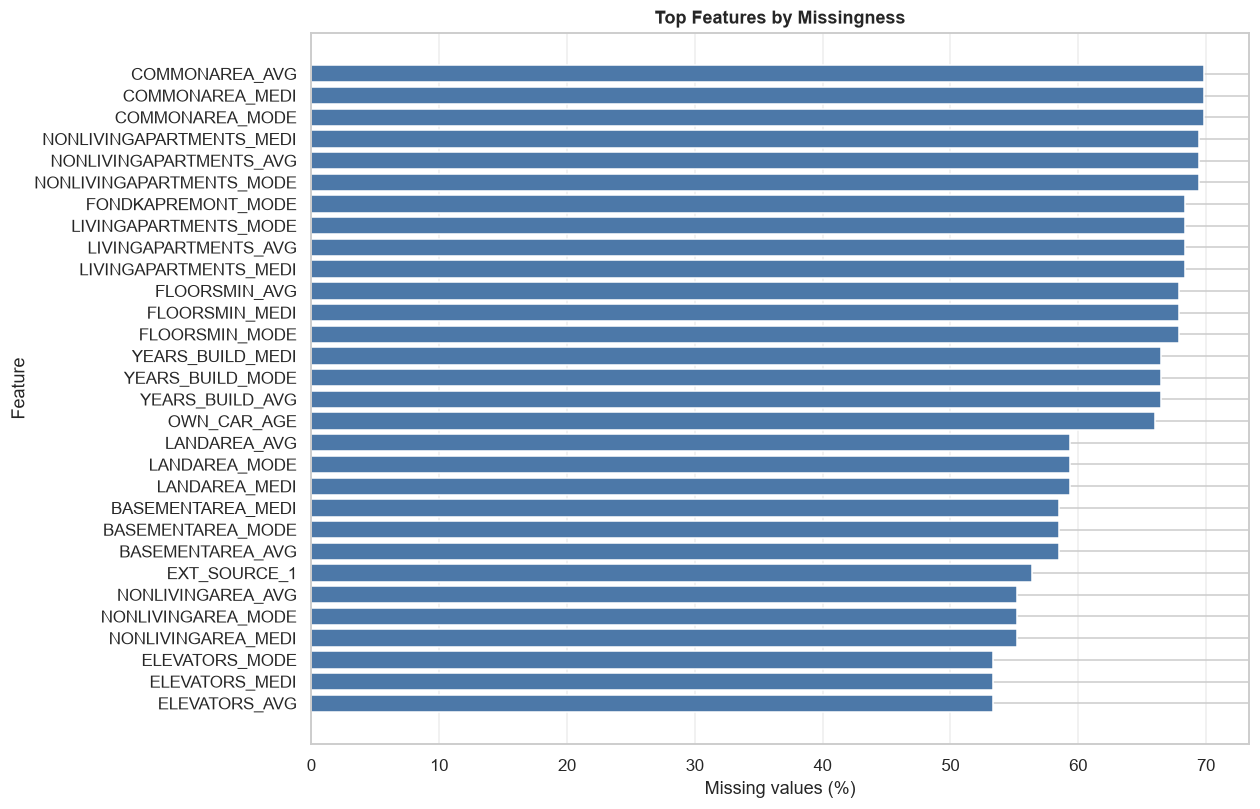

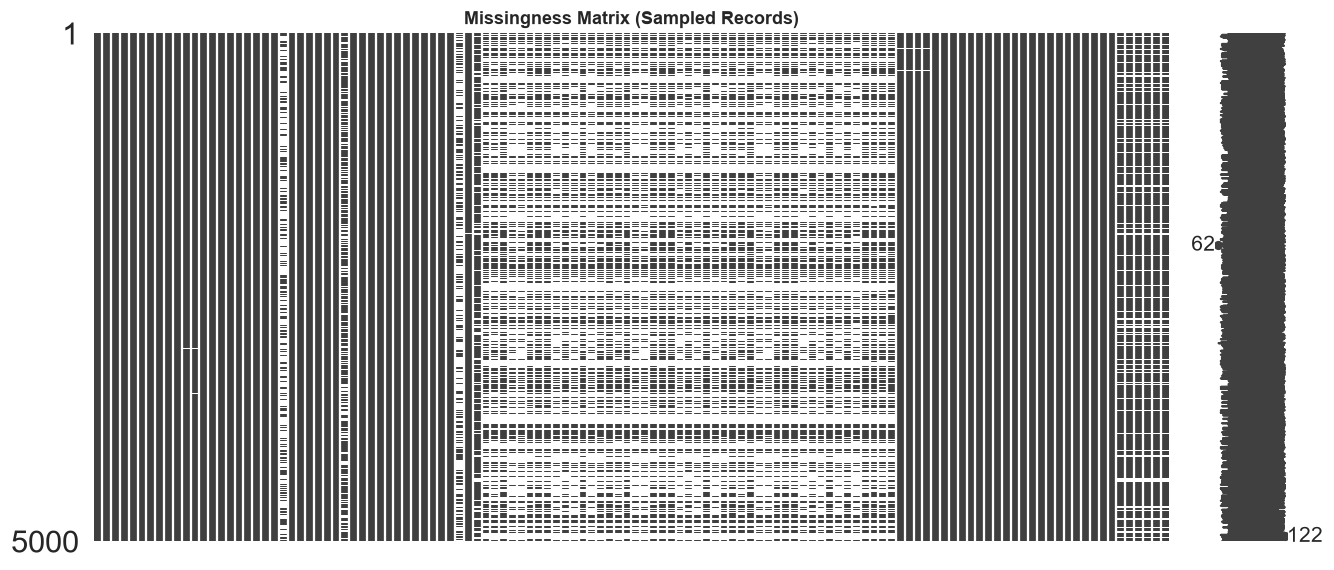

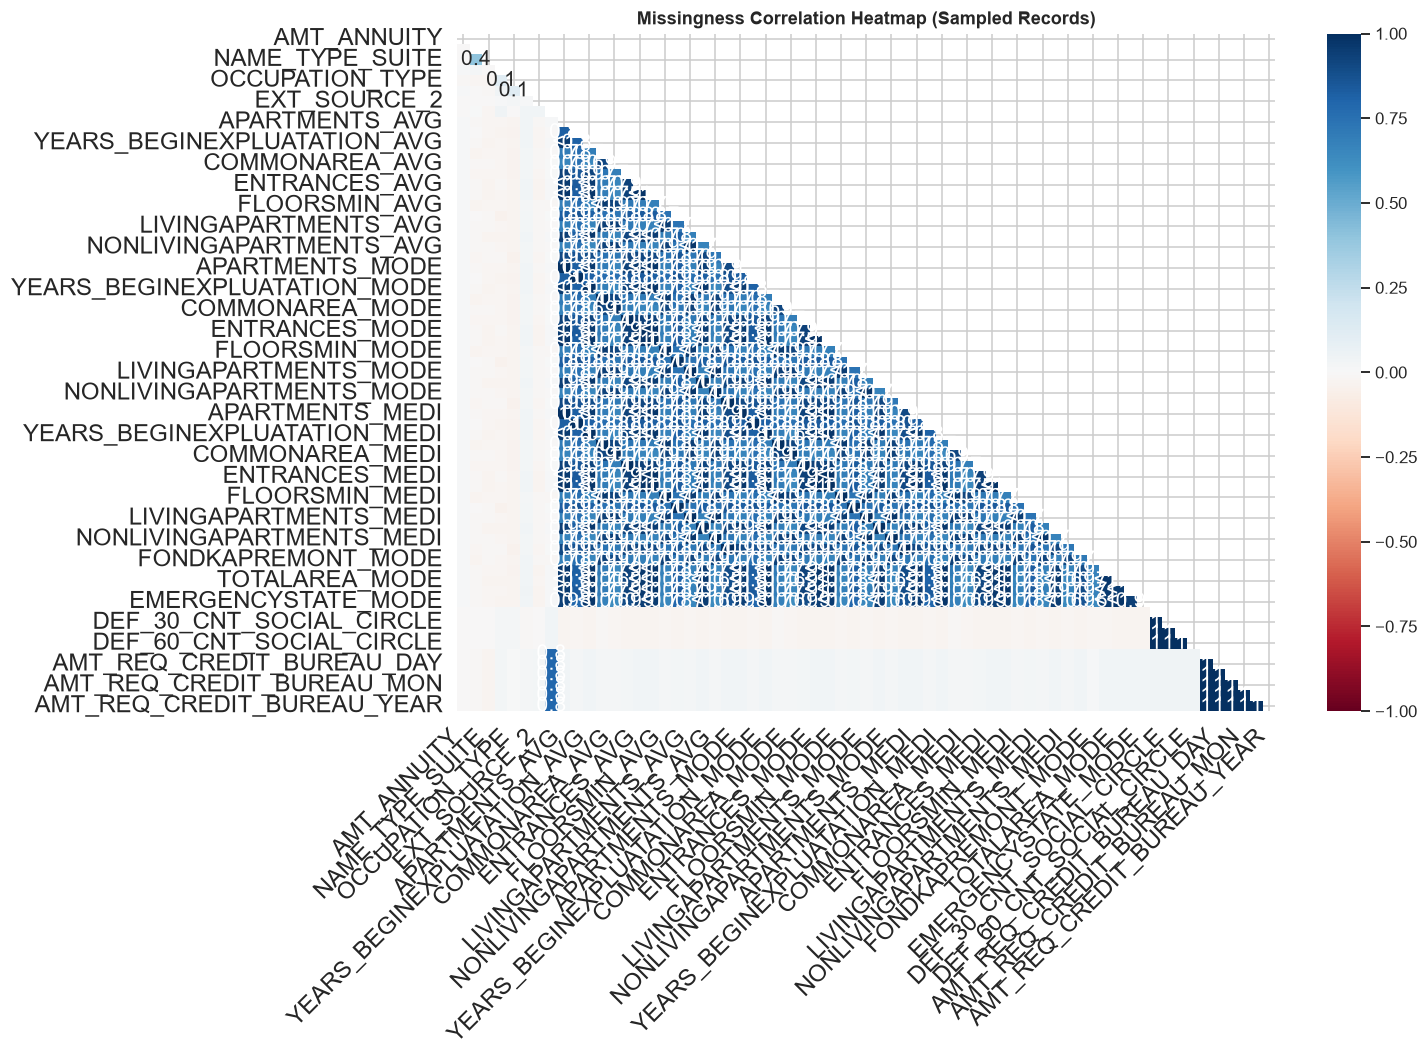

In [5]:
def missing_report(frame: pd.DataFrame) -> pd.DataFrame:
    """Return missing counts and percentages sorted by severity."""
    report = pd.DataFrame({"missing_count": frame.isna().sum()})
    report["missing_pct"] = report["missing_count"].div(len(frame)).mul(100)
    return report.query("missing_count > 0").sort_values("missing_pct", ascending=False)

missing = missing_report(df)
display(missing)
top_missing = missing.head(30).sort_values("missing_pct")
fig, ax = plt.subplots(figsize=(11, max(5, len(top_missing)*.28)))
ax.barh(top_missing.index, top_missing["missing_pct"], color="#4C78A8")
ax.set(title="Top Features by Missingness", xlabel="Missing values (%)", ylabel="Feature"); ax.grid(axis="x", alpha=.35); plt.show()
sample = df.sample(min(5_000, len(df)), random_state=RANDOM_STATE)
msno.matrix(sample, figsize=(14, 6)); plt.title("Missingness Matrix (Sampled Records)"); plt.show()
msno.heatmap(sample, figsize=(12, 8)); plt.title("Missingness Correlation Heatmap (Sampled Records)"); plt.show()

# 6 Duplicate Analysis

Exact duplicates can overweight repeated applications and artificially improve model results. We report them before changing data; if found, the original copy is retained and only the analytical frame is de-duplicated. Operationally, repeated applications should be investigated because they can represent valid resubmissions.

In [6]:
df_raw = df.copy()
duplicate_count = int(df.duplicated().sum())
print(f"Exact duplicate rows: {duplicate_count:,} ({duplicate_count / len(df):.2%})")
if duplicate_count:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed; analytical shape: {df.shape}")
else:
    print("No exact duplicates found; no rows were removed.")

Exact duplicate rows: 0 (0.00%)
No exact duplicates found; no rows were removed.


# 7 Target Variable Analysis

`TARGET` labels observed default. The class distribution determines whether accuracy is meaningful and whether rare defaults need special treatment. Missed defaults create financial loss, while excess false positives can exclude viable borrowers; therefore later models should emphasise ROC-AUC, PR-AUC, recall, calibration, and threshold trade-offs.

,count,percentage
TARGET,,
0,282686,91.927118
1,24825,8.072882


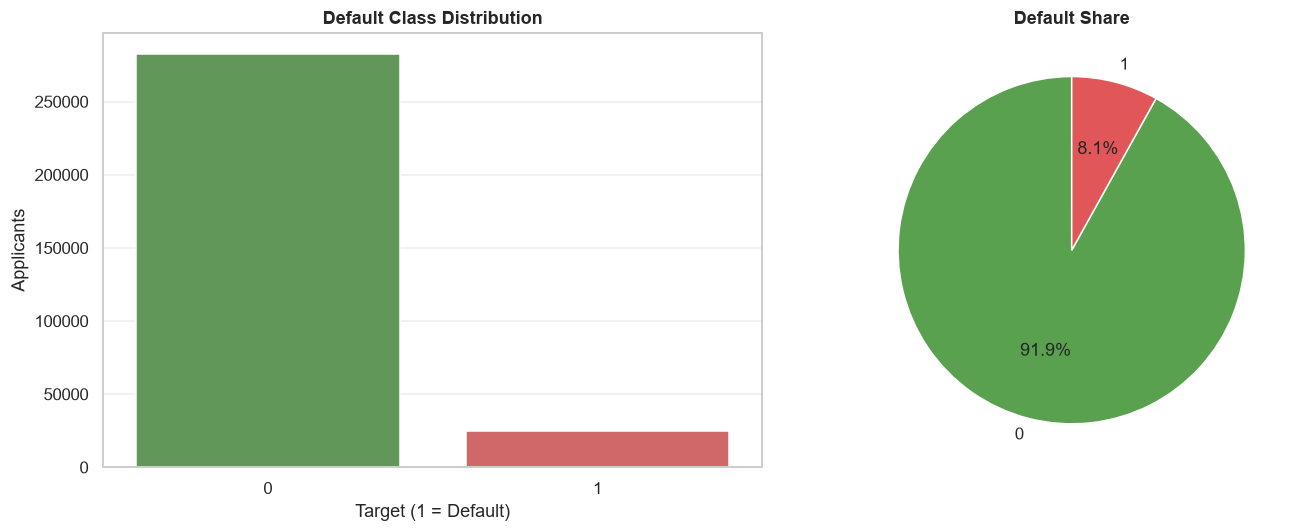

In [7]:
if TARGET not in df:
    raise KeyError(f"Expected target column {TARGET!r} was not found.")
target_summary = df[TARGET].value_counts(dropna=False).rename_axis(TARGET).to_frame("count")
target_summary["percentage"] = target_summary["count"].div(len(df)).mul(100)
display(target_summary)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x=TARGET, hue=TARGET, legend=False, palette=["#59A14F", "#E15759"], ax=axes[0])
axes[0].set(title="Default Class Distribution", xlabel="Target (1 = Default)", ylabel="Applicants"); axes[0].grid(axis="y", alpha=.35)
axes[1].pie(target_summary["count"], labels=target_summary.index, autopct="%1.1f%%", startangle=90, colors=["#59A14F", "#E15759"]); axes[1].set_title("Default Share")
plt.tight_layout(); plt.show()

# 8 Numerical Feature Analysis

Numerical distributions show typical applicant values, skewness, and extremes. Histograms with KDE reveal shape; boxplots expose spread. Skewness and kurtosis are diagnostics, not reasons to delete valid high-income or high-credit cases. In preprocessing, valid non-negative skewed features may be log-transformed and robustly scaled where evaluation supports it.

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
FLAG_MOBIL,307511.0,0.999997,0.001803,0.000000,1.000000,1.000000,1.000000,1.000000e+00,-554.536744,307511.000000
FLAG_DOCUMENT_12,307511.0,0.000007,0.002550,0.000000,0.000000,0.000000,0.000000,1.000000e+00,392.114779,153752.999974
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.000000,112500.000000,147150.000000,202500.000000,1.170000e+08,391.559654,191786.554381
FLAG_DOCUMENT_10,307511.0,0.000023,0.004771,0.000000,0.000000,0.000000,0.000000,1.000000e+00,209.589054,43925.857112
FLAG_DOCUMENT_2,307511.0,0.000042,0.006502,0.000000,0.000000,0.000000,0.000000,1.000000e+00,153.791817,23650.076908
...,...,...,...,...,...,...,...,...,...,...
REGION_RATING_CLIENT,307511.0,2.052463,0.509034,1.000000,2.000000,2.000000,2.000000,3.000000e+00,0.087468,0.800416
EXT_SOURCE_1,134133.0,0.502130,0.211062,0.014568,0.334007,0.505998,0.675053,9.626928e-01,-0.068755,-0.965155
REGION_RATING_CLIENT_W_CITY,307511.0,2.031521,0.502737,1.000000,2.000000,2.000000,2.000000,3.000000e+00,0.059730,0.933584
HOUR_APPR_PROCESS_START,307511.0,12.063419,3.265832,0.000000,10.000000,12.000000,14.000000,2.300000e+01,-0.028024,-0.194173


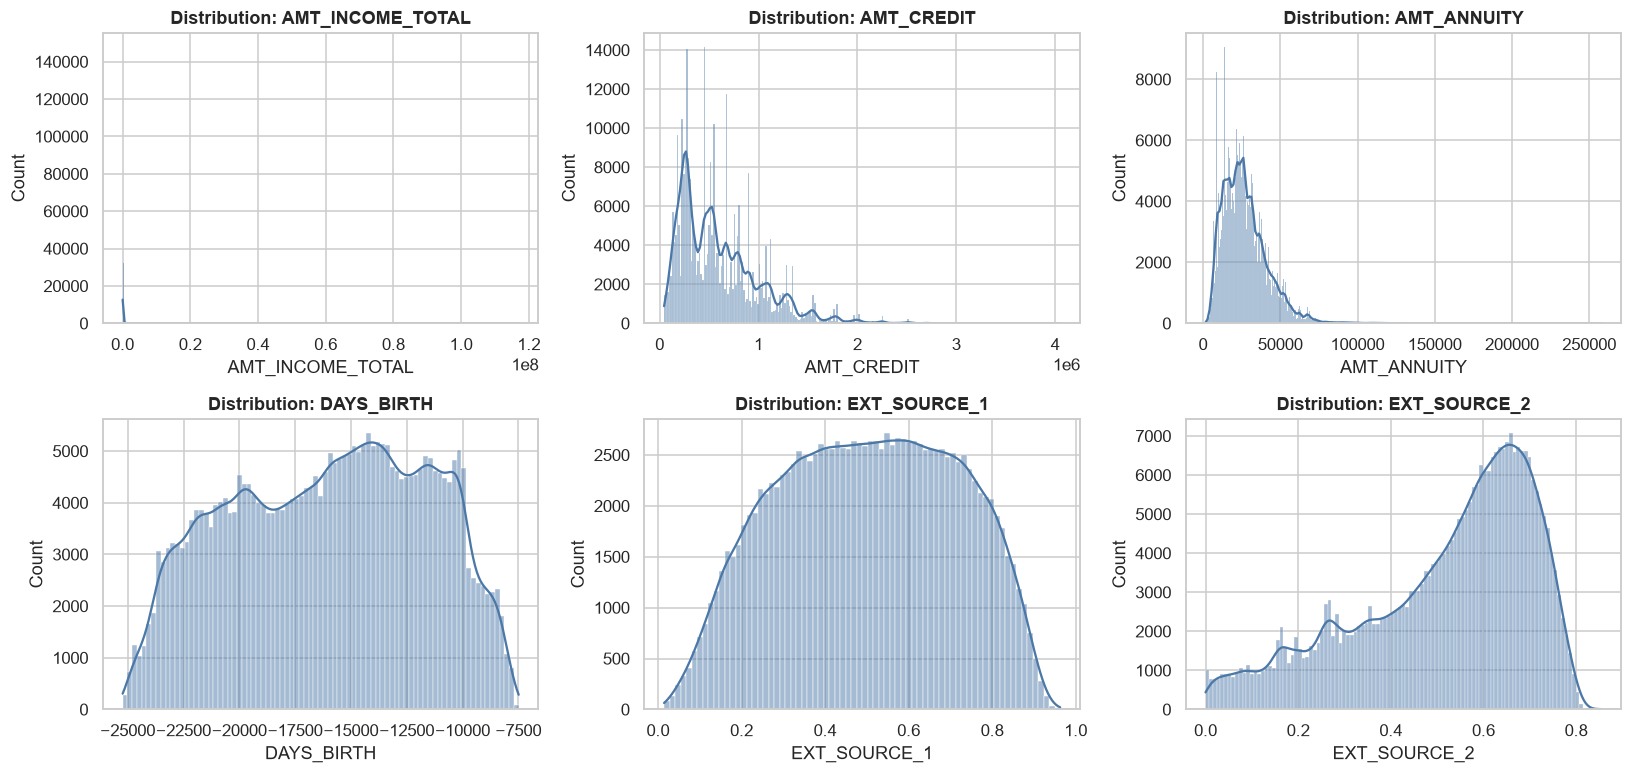

In [8]:
numeric_features = [c for c in groups["numerical"] if c != TARGET]
numeric_summary = df[numeric_features].describe().T
numeric_summary["skewness"], numeric_summary["kurtosis"] = df[numeric_features].skew(), df[numeric_features].kurt()
display(numeric_summary.sort_values("skewness", key=lambda x: x.abs(), ascending=False))

def plot_distributions(frame: pd.DataFrame, columns: Iterable[str], n_cols: int = 3) -> None:
    """Draw histogram and KDE plots for selected numeric features."""
    columns = list(columns); rows = int(np.ceil(len(columns)/n_cols))
    fig, axes = plt.subplots(rows, n_cols, figsize=(5*n_cols, 3.6*rows))
    for ax, column in zip(np.ravel(axes), columns):
        sns.histplot(frame[column].dropna(), kde=True, color="#4C78A8", ax=ax)
        ax.set(title=f"Distribution: {column}", xlabel=column, ylabel="Count")
    for ax in np.ravel(axes)[len(columns):]: ax.remove()
    plt.tight_layout(); plt.show()

priority = [c for c in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "EXT_SOURCE_1", "EXT_SOURCE_2"] if c in df]
plot_distributions(df, priority)

# 9 Categorical Feature Analysis

Categorical fields capture applicant context such as contract, employment, family, and housing. Frequency tables reveal dominant and rare groups; cardinality identifies fields that require careful encoding; missing categories are kept visible because “unknown” can carry risk information. Rare categories may later need grouping to avoid unstable estimates.

,unique_categories,missing_count,missing_pct
ORGANIZATION_TYPE,58,0,0.000000
OCCUPATION_TYPE,18,96391,31.345545
NAME_INCOME_TYPE,8,0,0.000000
NAME_TYPE_SUITE,7,1292,0.420148
WALLSMATERIAL_MODE,7,156341,50.840783
WEEKDAY_APPR_PROCESS_START,7,0,0.000000
NAME_FAMILY_STATUS,6,0,0.000000
NAME_HOUSING_TYPE,6,0,0.000000
NAME_EDUCATION_TYPE,5,0,0.000000
FONDKAPREMONT_MODE,4,210295,68.386172


,count
NAME_CONTRACT_TYPE,
Cash loans,278232
Revolving loans,29279


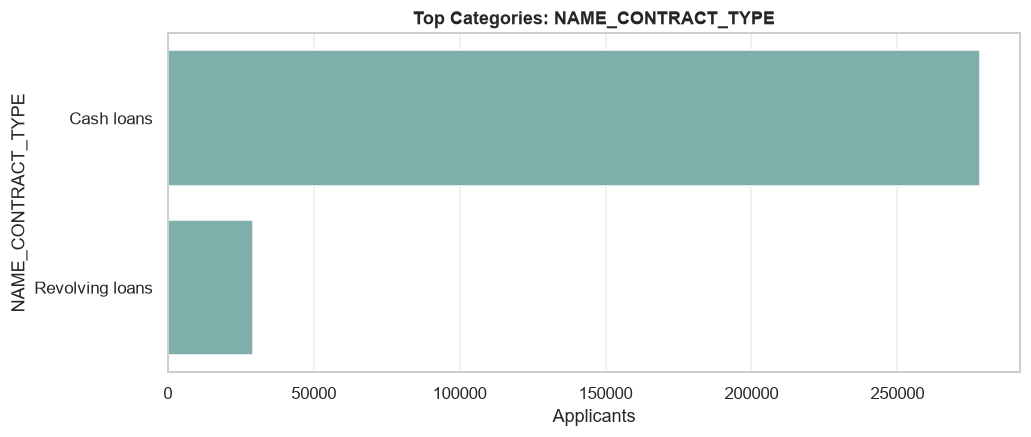

,count
FLAG_OWN_CAR,
N,202924
Y,104587


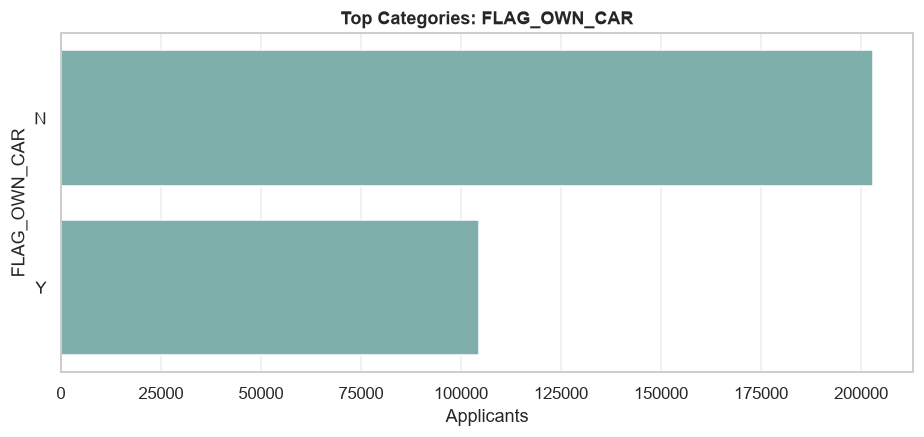

,count
FLAG_OWN_REALTY,
Y,213312
N,94199


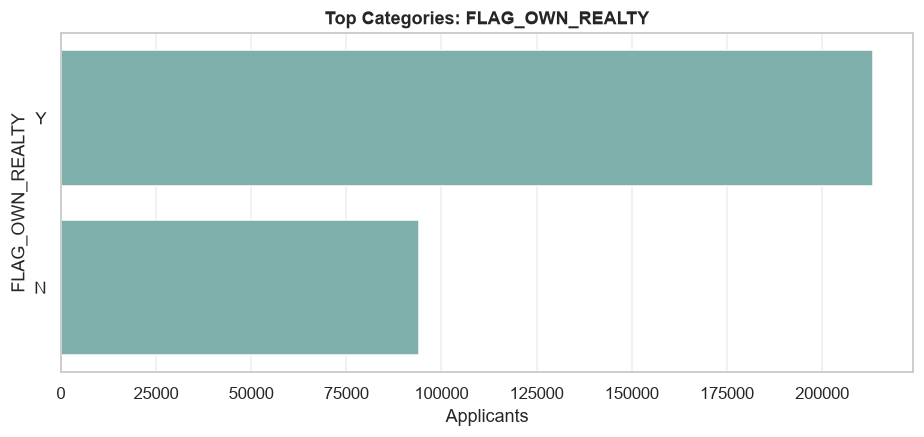

,count
EMERGENCYSTATE_MODE,
No,159428
Missing,145755
Yes,2328


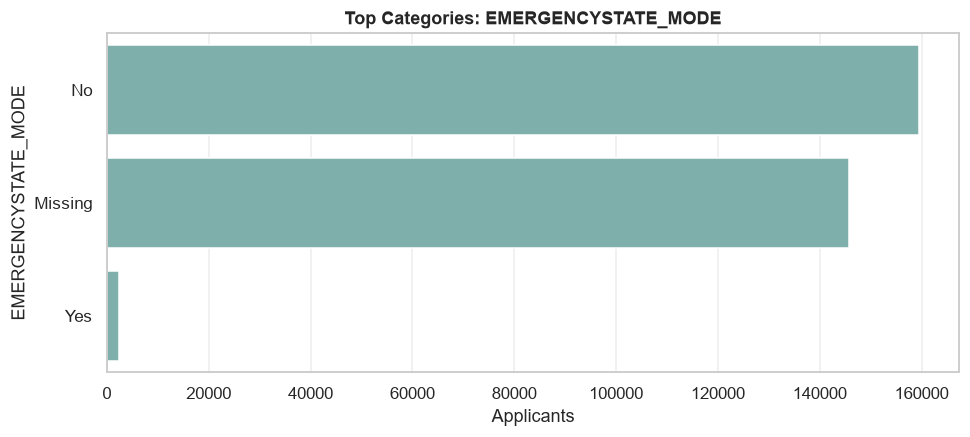

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


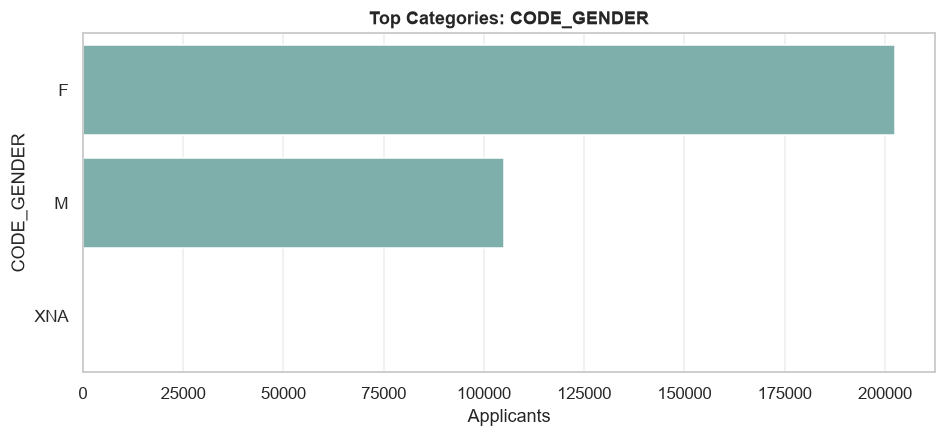

,count
HOUSETYPE_MODE,
Missing,154297
block of flats,150503
specific housing,1499
terraced house,1212


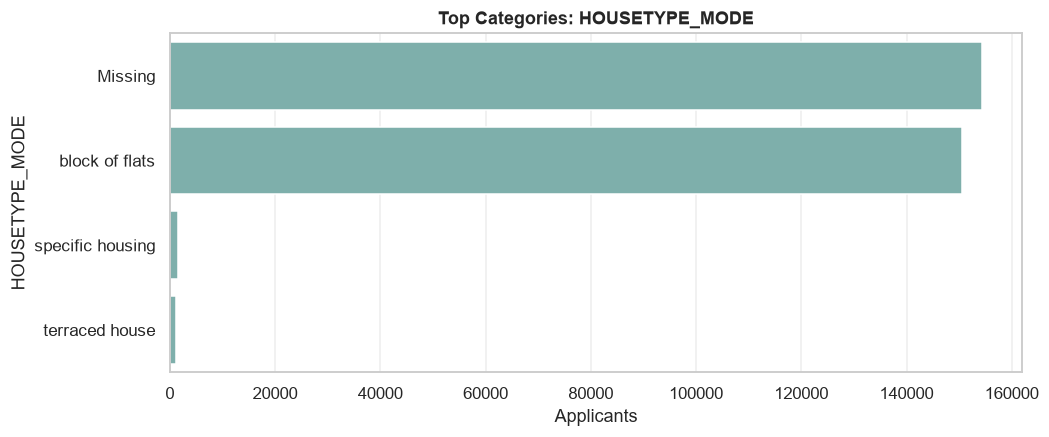

,count
FONDKAPREMONT_MODE,
Missing,210295
reg oper account,73830
reg oper spec account,12080
not specified,5687
org spec account,5619


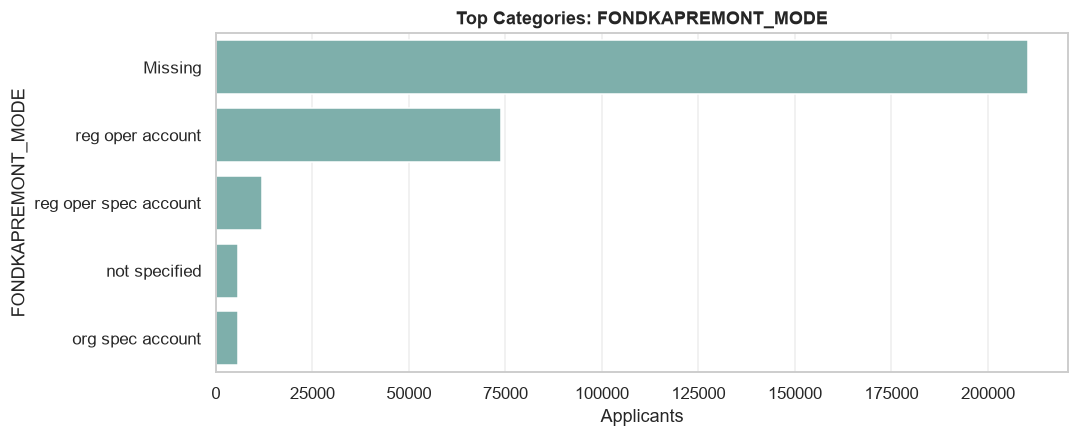

,count
NAME_EDUCATION_TYPE,
Secondary / secondary special,218391
Higher education,74863
Incomplete higher,10277
Lower secondary,3816
Academic degree,164


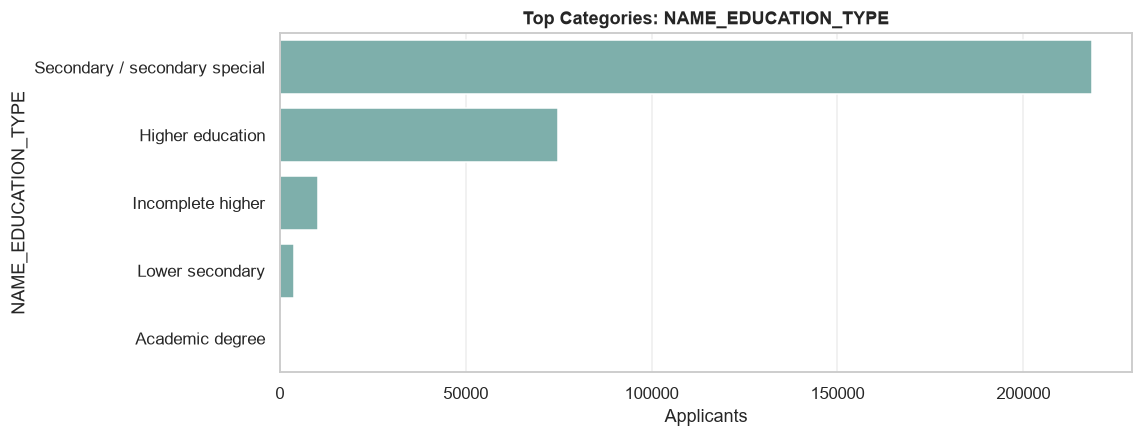

In [9]:
categorical_profile = pd.DataFrame({"unique_categories": df[groups["categorical"]].nunique(), "missing_count": df[groups["categorical"]].isna().sum(), "missing_pct": df[groups["categorical"]].isna().mean().mul(100)}).sort_values("unique_categories", ascending=False)
display(categorical_profile)
for column in sorted(groups["categorical"], key=lambda c: df[c].nunique())[:8]:
    frequency = df[column].fillna("Missing").value_counts().head(15)
    display(frequency.rename("count").to_frame().rename_axis(column))
    plt.figure(figsize=(10, 4)); sns.countplot(data=df.assign(**{column: df[column].fillna("Missing")}), y=column, order=frequency.index, color="#76B7B2")
    plt.title(f"Top Categories: {column}"); plt.xlabel("Applicants"); plt.ylabel(column); plt.grid(axis="x", alpha=.35); plt.show()

# 10 Correlation Analysis

Correlation measures linear association, not causation or non-linear influence. Positive target correlation means a feature tends to increase with observed default; negative correlation means it tends to coincide with repayment. The heatmap spots redundant numerical variables and candidate signals, which must be validated later with held-out models and explainability methods.

,correlation_with_target
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_EMPLOYED,-0.044932
FLOORSMAX_AVG,-0.044003
FLOORSMAX_MEDI,-0.043768
FLOORSMAX_MODE,-0.043226
AMT_GOODS_PRICE,-0.039645
REGION_POPULATION_RELATIVE,-0.037227
ELEVATORS_AVG,-0.034199


,correlation_with_target
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982
REG_CITY_NOT_LIVE_CITY,0.044395
FLAG_DOCUMENT_3,0.044346
DAYS_REGISTRATION,0.041975


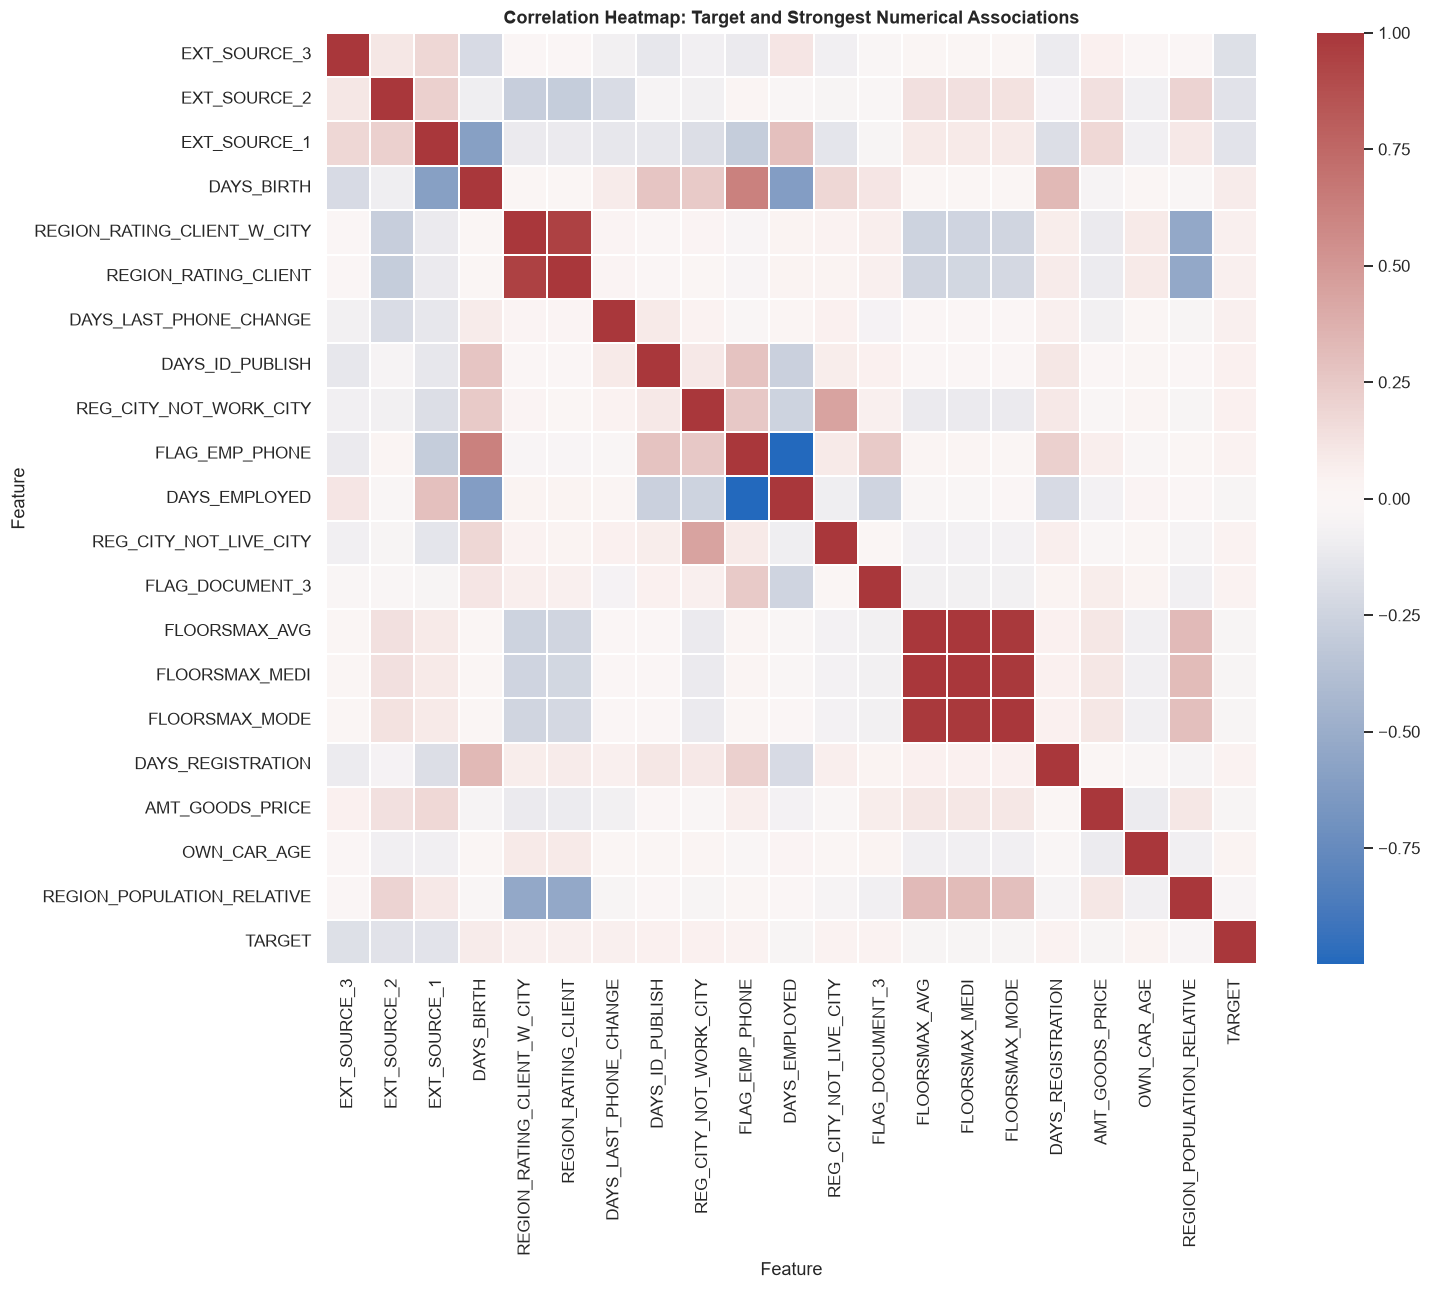

In [10]:
correlation = df[groups["numerical"]].corr(numeric_only=True)
target_correlation = correlation[TARGET].drop(TARGET).sort_values()
display(target_correlation.head(15).rename("correlation_with_target").to_frame())
display(target_correlation.tail(15).sort_values(ascending=False).rename("correlation_with_target").to_frame())
selected = list(target_correlation.abs().nlargest(min(20, len(target_correlation))).index) + [TARGET]
plt.figure(figsize=(14, 11)); sns.heatmap(df[selected].corr(), cmap="vlag", center=0, square=True, linewidths=.3)
plt.title("Correlation Heatmap: Target and Strongest Numerical Associations"); plt.xlabel("Feature"); plt.ylabel("Feature"); plt.show()

# 11 Outlier Analysis

IQR flags provide a robust, transparent view of unusually low or high values. Flags are diagnostic rather than automatic deletion: extreme but valid loans and incomes may be highly relevant to risk. Preprocessing should verify plausibility and prefer capping, robust scaling, or transformations over indiscriminate row removal.

,feature,outlier_count,outlier_pct
19,REGION_RATING_CLIENT,80527,26.186706
20,REGION_RATING_CLIENT_W_CITY,78027,25.373726
8,DAYS_EMPLOYED,72217,23.484363
26,REG_CITY_NOT_WORK_CITY,70867,23.045354
14,FLAG_WORK_PHONE,61308,19.936848
103,AMT_REQ_CREDIT_BUREAU_QRT,50575,19.013730
13,FLAG_EMP_PHONE,55386,18.011063
27,LIVE_CITY_NOT_WORK_CITY,55215,17.955455
43,NONLIVINGAPARTMENTS_AVG,15580,16.574997
102,AMT_REQ_CREDIT_BUREAU_MON,43759,16.451247


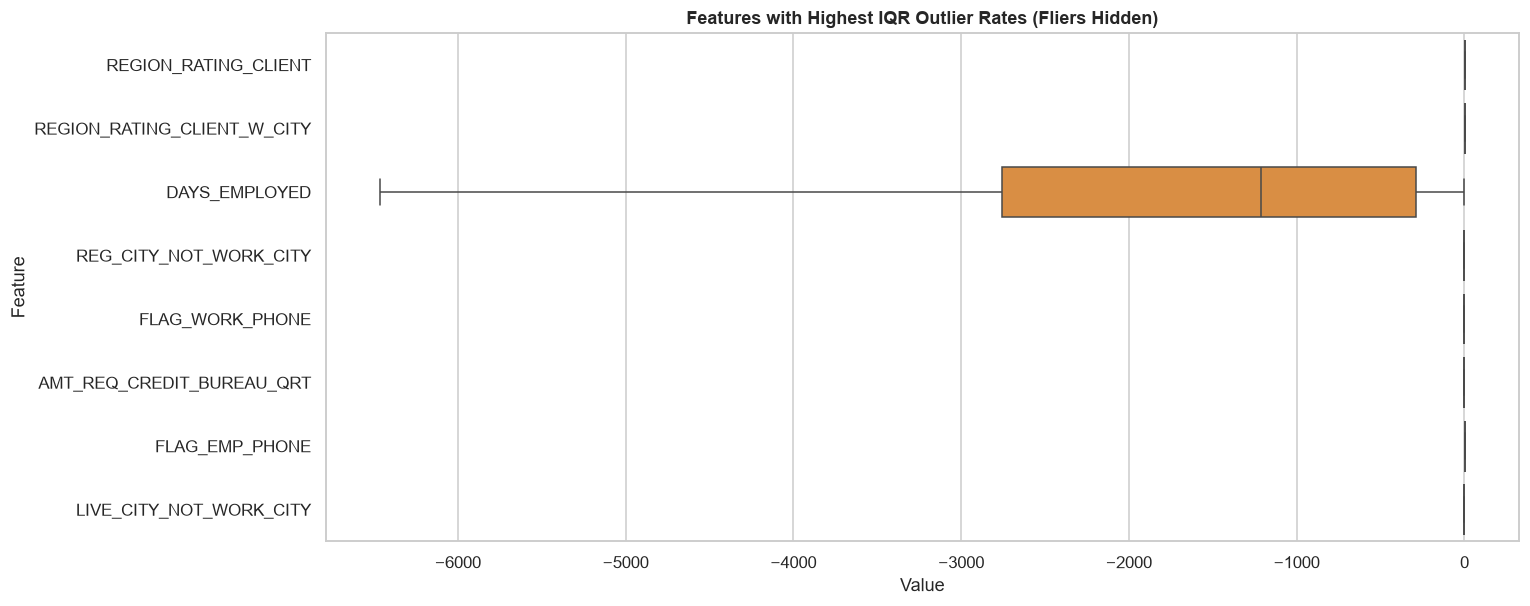

In [11]:
def iqr_outlier_report(frame: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """Calculate IQR-based outlier counts and rates."""
    rows = []
    for column in columns:
        values = frame[column].dropna(); q1, q3 = values.quantile([.25, .75]); iqr = q3-q1
        count = ((values < q1-1.5*iqr) | (values > q3+1.5*iqr)).sum()
        rows.append((column, int(count), count/len(values)*100))
    return pd.DataFrame(rows, columns=["feature", "outlier_count", "outlier_pct"]).sort_values("outlier_pct", ascending=False)

outliers = iqr_outlier_report(df, numeric_features); display(outliers.head(20))
box_features = list(outliers.head(8)["feature"])
plt.figure(figsize=(14, 6)); sns.boxplot(data=df[box_features], orient="h", color="#F28E2B", showfliers=False)
plt.title("Features with Highest IQR Outlier Rates (Fliers Hidden)"); plt.xlabel("Value"); plt.ylabel("Feature"); plt.show()

# 12 Feature Distribution

Comparing important variables by default outcome shows whether classes differ in a potentially useful way. Separation suggests predictive signal; overlap suggests risk depends on multiple variables and non-linear interactions. This also points to transformations and scaling choices that will be tested rather than assumed.

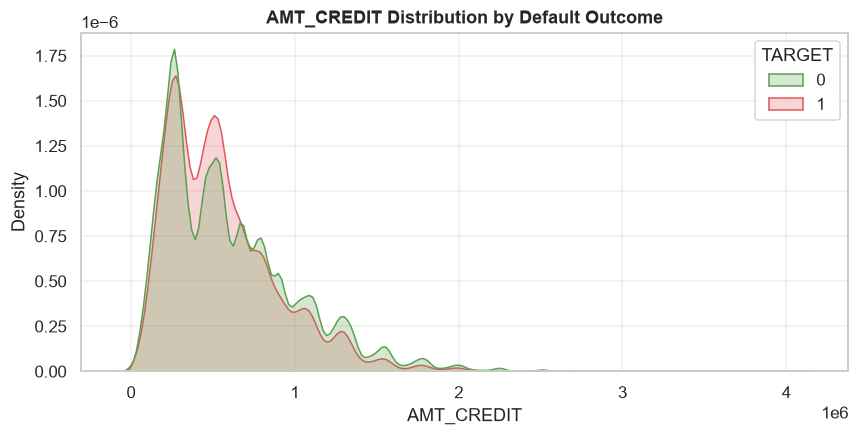

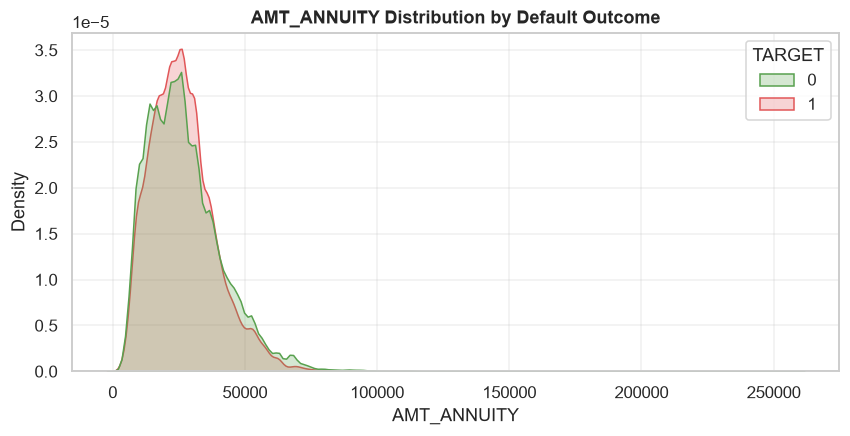

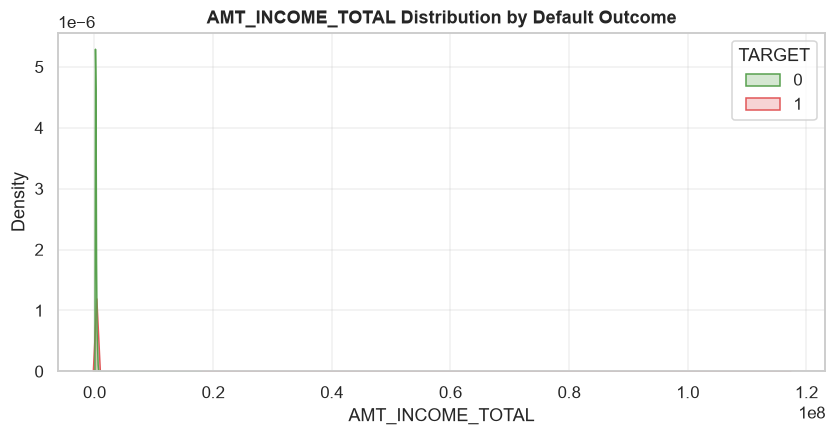

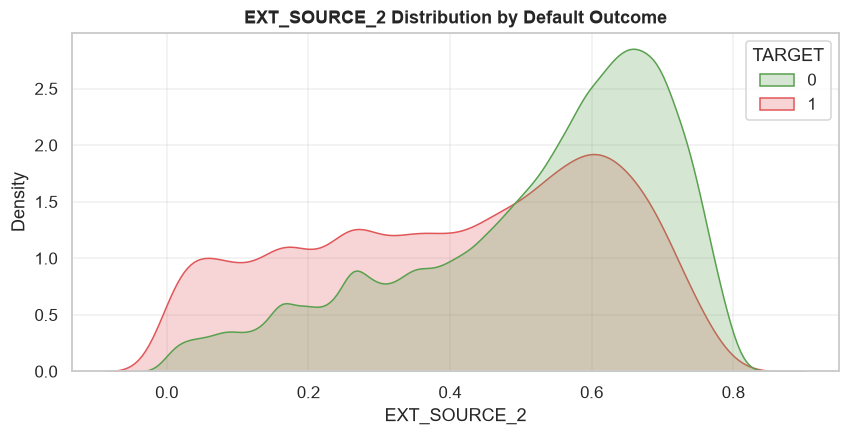

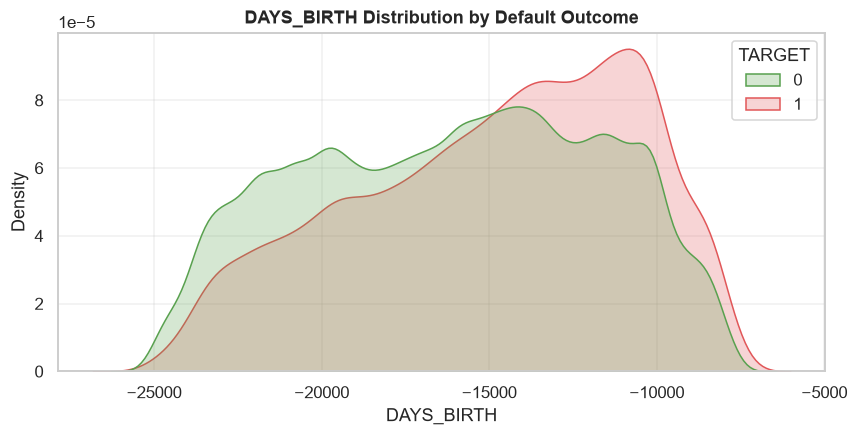

In [12]:
for column in [c for c in ["AMT_CREDIT", "AMT_ANNUITY", "AMT_INCOME_TOTAL", "EXT_SOURCE_2", "DAYS_BIRTH"] if c in df]:
    plt.figure(figsize=(9, 4))
    sns.kdeplot(data=df[[column, TARGET]].dropna(), x=column, hue=TARGET, common_norm=False, fill=True, alpha=.25, palette=["#59A14F", "#E15759"])
    plt.title(f"{column} Distribution by Default Outcome"); plt.xlabel(column); plt.ylabel("Density"); plt.grid(alpha=.3); plt.show()

# 13 Key Business Insights

This concise evidence briefing reports default exposure, completeness, duplicates, and the strongest linear associations. These findings are not causal rules for lending. They identify candidates for further validation, feature engineering, fairness assessment, and local explanations.

In [13]:
insights = {"Default rate": f"{df[TARGET].mean():.2%}", "Features with missing values": len(missing), "Highest missingness": f"{missing['missing_pct'].max():.2f}%" if len(missing) else "0.00%", "Exact duplicates found": duplicate_count, "Strongest positive target correlation": target_correlation.idxmax(), "Strongest negative target correlation": target_correlation.idxmin()}
display(pd.Series(insights, name="Finding").to_frame())
print("Business: risk signals support consistent review; they do not replace governance.")
print("ML: preserve meaningful missingness, address imbalance, and validate all transformations.")

,Finding
Default rate,8.07%
Features with missing values,67
Highest missingness,69.87%
Exact duplicates found,0
Strongest positive target correlation,DAYS_BIRTH
Strongest negative target correlation,EXT_SOURCE_3


Business: risk signals support consistent review; they do not replace governance.
ML: preserve meaningful missingness, address imbalance, and validate all transformations.


# 14 Data Quality Report

This report consolidates EDA diagnostics into transparent preprocessing priorities. It does not silently alter the data; instead it records the trade-offs for reproducible imputation, encoding, outlier handling, and imbalance treatment. Such traceability is fundamental to credit-risk model governance.

In [14]:
quality_report = pd.DataFrame({"Metric": ["Rows analysed", "Columns analysed", "Features with missing values", "Exact duplicates", "Numerical features", "Categorical features", "Boolean features", "Default rate", "Features with IQR outliers"], "Value": [len(df), df.shape[1], len(missing), duplicate_count, len(groups["numerical"]), len(groups["categorical"]), len(groups["boolean"]), f"{df[TARGET].mean():.2%}", int((outliers["outlier_count"] > 0).sum())], "Potential issue": ["Dataset scale", "Schema breadth", "Imputation and indicators", "Potential repetition", "Scaling / skew / outliers", "Encoding and cardinality", "Boolean conversion", "Imbalanced learning", "Validate and cap only implausible values"]})
display(quality_report)

,Metric,Value,Potential issue
0,Rows analysed,307511,Dataset scale
1,Columns analysed,122,Schema breadth
2,Features with missing values,67,Imputation and indicators
3,Exact duplicates,0,Potential repetition
4,Numerical features,106,Scaling / skew / outliers
5,Categorical features,16,Encoding and cardinality
6,Boolean features,0,Boolean conversion
7,Default rate,8.07%,Imbalanced learning
8,Features with IQR outliers,97,Validate and cap only implausible values


# 15 Conclusion

This notebook profiled the Home Credit data, assessed completeness and duplicates, quantified default imbalance, and examined numerical, categorical, correlation, outlier, and target-separated patterns. It provides an evidence base for responsible modelling without discarding potentially meaningful borrower information.

Next: **02_Preprocessing.ipynb** will create reproducible train/validation/test splits, encode categories, impute missing values with indicators, apply justified transformations or robust scaling, and address class imbalance within training only. Every choice should be validated for predictive performance, calibration, fairness, and explainability before deployment.